# EDA и моделирование — Predictive Maintenance
# EDA and Modeling — Predictive Maintenance

Разведочный анализ данных и подготовка к построению модели бинарной классификации отказов оборудования.  
Exploratory data analysis and preparation for binary failure classification.

## План работы / Work plan

1. **Загрузка данных** — чтение CSV из `data/raw/`.
2. **Базовая информация** — shape, колонки, типы, пропуски.
3. **Первые строки** — быстрый обзор структуры записей.
4. **Матрица корреляции** — heatmap числовых признаков.
5. **Целевая переменная** — распределение `Target` (0 — нет отказа, 1 — отказ).
6. **Предобработка** — кодирование признаков, train/test split, стандартизация.

> Дальнейшие шаги (модели LR, RF, XGBoost) будут добавлены в следующих ячейках ноутбука.

In [9]:
# Импорты / Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Стиль графиков / Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

## 1. Загрузка датасета / Dataset loading

In [10]:
# Путь к данным относительно корня проекта / Path relative to project root
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "predictive_maintenance.csv"

# Загрузка CSV / Load CSV
df = pd.read_csv(DATA_PATH)

print(f"Файл загружен / File loaded: {DATA_PATH.name}")
print(f"Строк / Rows: {len(df):,}")

Файл загружен / File loaded: predictive_maintenance.csv
Строк / Rows: 10,000


## 2. Базовая информация о данных / Basic data overview

In [11]:
# Размерность / Shape
print("=" * 50)
print("Размерность (строки, столбцы) / Shape (rows, columns):")
print(df.shape)

print("\n" + "=" * 50)
print("Названия колонок / Column names:")
print(list(df.columns))

print("\n" + "=" * 50)
print("Типы данных / Data types:")
print(df.dtypes)

print("\n" + "=" * 50)
print("Пропущенные значения / Missing values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_df[missing_df["missing_count"] > 0] if missing.sum() > 0 else "Пропусков нет / No missing values")

print("\n" + "=" * 50)
print("Краткая статистика числовых признаков / Numeric summary:")
display(df.describe())

Размерность (строки, столбцы) / Shape (rows, columns):
(10000, 10)

Названия колонок / Column names:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']

Типы данных / Data types:
UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                   str
dtype: object

Пропущенные значения / Missing values:
Пропусков нет / No missing values

Краткая статистика числовых признаков / Numeric summary:


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


## 3. Первые строки датасета / First rows preview

In [12]:
# Просмотр первых 10 записей / View first 10 records
df.head(10)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure
5,6,M14865,M,298.1,308.6,1425,41.9,11,0,No Failure
6,7,L47186,L,298.1,308.6,1558,42.4,14,0,No Failure
7,8,L47187,L,298.1,308.6,1527,40.2,16,0,No Failure
8,9,M14868,M,298.3,308.7,1667,28.6,18,0,No Failure
9,10,M14869,M,298.5,309.0,1741,28.0,21,0,No Failure


## 4. Матрица корреляции признаков / Feature correlation matrix

Для корреляции используем только числовые столбцы.  
Only numeric columns are used for the correlation matrix.

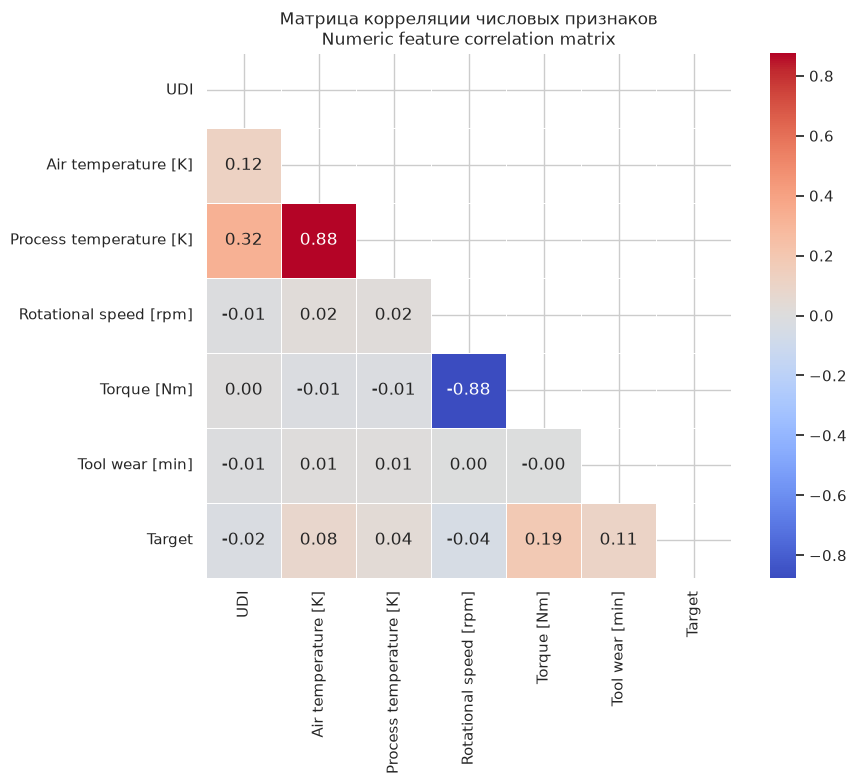

In [13]:
# Выбираем числовые признаки / Select numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

# Heatmap / Тепловая карта
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # верхний треугольник / upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Матрица корреляции числовых признаков\nNumeric feature correlation matrix")
plt.tight_layout()
plt.show()

## 5. Распределение целевой переменной / Target variable distribution

В данном датасете бинарная метка отказа хранится в столбце **`Target`** (0 — нет отказа, 1 — отказ).  
In this dataset, the binary failure label is in **`Target`** (0 = no failure, 1 = failure).

In [14]:
# Целевая переменная / Target variable
target_col = "Target"

# Подсчёт классов / Class counts
class_counts = df[target_col].value_counts().sort_index()
class_pct = (class_counts / len(df) * 100).round(2)

print("Распределение целевой переменной / Target distribution:")
for label, count in class_counts.items():
    label_name = "Target=0 (нет отказа)" if label == 0 else "Target=1 (отказ)"
    print(f"  {label_name}: {count:,} ({class_pct[label]}%)")

print(f"\nДисбаланс классов / Class imbalance ratio: {class_counts[0] / class_counts[1]:.1f} : 1")

Распределение целевой переменной / Target distribution:
  Target=0 (нет отказа): 9,661 (96.61%)
  Target=1 (отказ): 339 (3.39%)

Дисбаланс классов / Class imbalance ratio: 28.5 : 1


/tmp/ipykernel_22727/1391491276.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, ax=axes[0], palette=colors)
/tmp/ipykernel_22727/1391491276.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(labels)


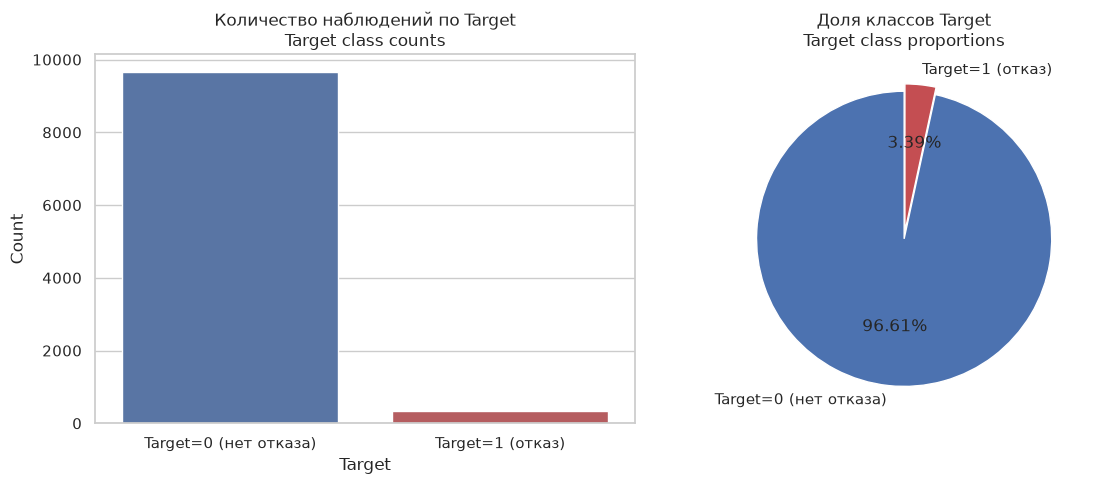

In [15]:
# Визуализация: countplot + pie chart / Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Target=0 (нет отказа)", "Target=1 (отказ)"]
colors = ["#4C72B0", "#C44E52"]

# Столбчатая диаграмма / Bar chart
sns.countplot(data=df, x=target_col, ax=axes[0], palette=colors)
axes[0].set_title("Количество наблюдений по Target\nTarget class counts")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(labels)

# Круговая диаграмма / Pie chart
axes[1].pie(
    class_counts,
    labels=labels,
    autopct="%1.2f%%",
    colors=colors,
    startangle=90,
    explode=(0, 0.05),
)
axes[1].set_title("Доля классов Target\nTarget class proportions")

plt.tight_layout()
plt.show()

Типы отказов (Failure Type) среди случаев с Target=1:
Failure Type
Heat Dissipation Failure    112
Power Failure                95
Overstrain Failure           78
Tool Wear Failure            45
No Failure                    9
Name: count, dtype: int64


/tmp/ipykernel_22727/3396562235.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=failure_types.index, y=failure_types.values, ax=ax, palette="Reds_r")


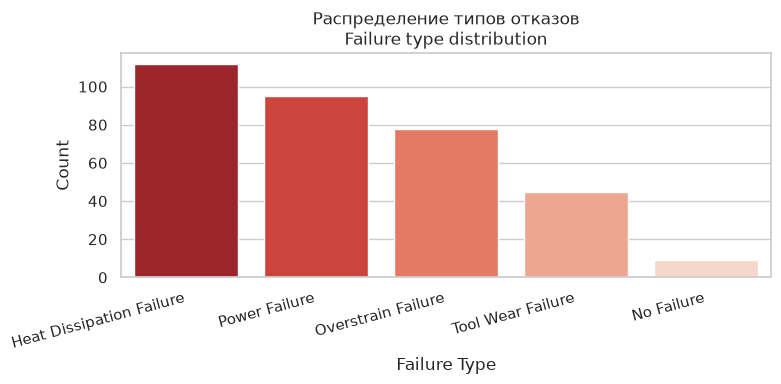

In [16]:
# Типы отказов среди положительного класса / Failure types among positive class
if "Failure Type" in df.columns:
    failure_types = (
        df.loc[df[target_col] == 1, "Failure Type"]
        .value_counts()
    )
    print("Типы отказов (Failure Type) среди случаев с Target=1:")
    print(failure_types)

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(x=failure_types.index, y=failure_types.values, ax=ax, palette="Reds_r")
    ax.set_title("Распределение типов отказов\nFailure type distribution")
    ax.set_xlabel("Failure Type")
    ax.set_ylabel("Count")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

## 6. Предобработка данных для моделирования / Data preprocessing for modeling

Подготовка признаков перед обучением: кодирование категорий, разбиение на train/test и стандартизация числовых столбцов.  
Feature preparation before training: categorical encoding, train/test split, and numeric standardization.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Копия данных — исходный df не изменяем / Copy — keep original df intact
df_model = df.copy()

# 2. Целевая переменная y = Target / Target variable
y = df_model["Target"]

# 3. Инженерия признаков / Feature engineering
# Product ID: первые 2 символа — подтип продукта (L4, L5, M1, M2, H2, H3)
# Product ID: first 2 chars encode product sub-type (L4, L5, M1, M2, H2, H3)
df_model["Product_ID_prefix"] = df_model["Product ID"].astype(str).str[:2]

# Признаки X: убираем служебные и целевые колонки / Features X: drop ID, target, leakage
drop_cols = ["UDI", "Product ID", "Target", "Failure Type"]
X = df_model.drop(columns=drop_cols)

# 4. Типы признаков / Feature types
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]
categorical_cols = ["Type", "Product_ID_prefix"]

print("Числовые признаки / Numeric features:")
print(numeric_cols)
print("\nКатегориальные признаки / Categorical features:")
print(categorical_cols)

# 5. One-Hot Encoding для категориальных признаков / One-hot encode categoricals
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# 6. Разбиение train (80%) / test (20%) / Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,  # сохраняем долю классов Target / preserve Target class ratio
)

# 7. Стандартизация числовых признаков: fit на train, transform на train и test
# Standardize numeric features: fit on train, transform train and test
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# 8. Размеры выборок и первые строки X_train / Sample sizes and X_train preview
print("\n" + "=" * 50)
print("Размеры выборок / Sample shapes:")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"  y_train: {y_train.shape}  |  y_test: {y_test.shape}")

print("\nПервые 5 строк X_train / First 5 rows of X_train:")
display(X_train.head())

print("\nПредобработка завершена. Данные готовы к обучению моделей.")
print("Preprocessing complete. Data is ready for model training.")

Числовые признаки / Numeric features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Категориальные признаки / Categorical features:
['Type', 'Product_ID_prefix']

Размеры выборок / Sample shapes:
  X_train: (8000, 14)  |  X_test: (2000, 14)
  y_train: (8000,)  |  y_test: (2000,)

Первые 5 строк X_train / First 5 rows of X_train:


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M,Product_ID_prefix_H2,Product_ID_prefix_H3,Product_ID_prefix_L4,Product_ID_prefix_L5,Product_ID_prefix_M1,Product_ID_prefix_M2
4058,0.998914,0.604282,-0.460607,0.718305,-0.843997,False,False,True,False,False,False,False,True,False
1221,-1.505194,-1.153260,-0.775574,0.638456,0.382263,False,False,True,False,False,False,False,True,False
6895,0.498092,1.077466,-1.007654,0.558607,0.460870,False,False,True,False,False,False,False,False,True
9863,-0.553633,-0.139294,-0.709265,1.626586,-0.372359,False,True,False,False,False,False,True,False,False
8711,-1.455112,-1.018064,1.070019,-1.128202,-0.906882,False,True,False,False,False,False,True,False,False



Предобработка завершена. Данные готовы к обучению моделей.
Preprocessing complete. Data is ready for model training.
